In [6]:
words = open('names.txt',"r",).read().splitlines()

In [7]:
b={}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1,ch2 in zip(chs,chs[1:]):
        bigram =  (ch1,ch2)
        b[bigram] = b.get(bigram,0) + 1

In [8]:
sorted(b.items(),key= lambda kv : -kv[1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [9]:
import torch
N = torch.zeros((27,27),dtype=torch.int32)

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0

itos = {i:s for s,i in stoi.items()}


for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]

        N[ix1,ix2] += 1
        

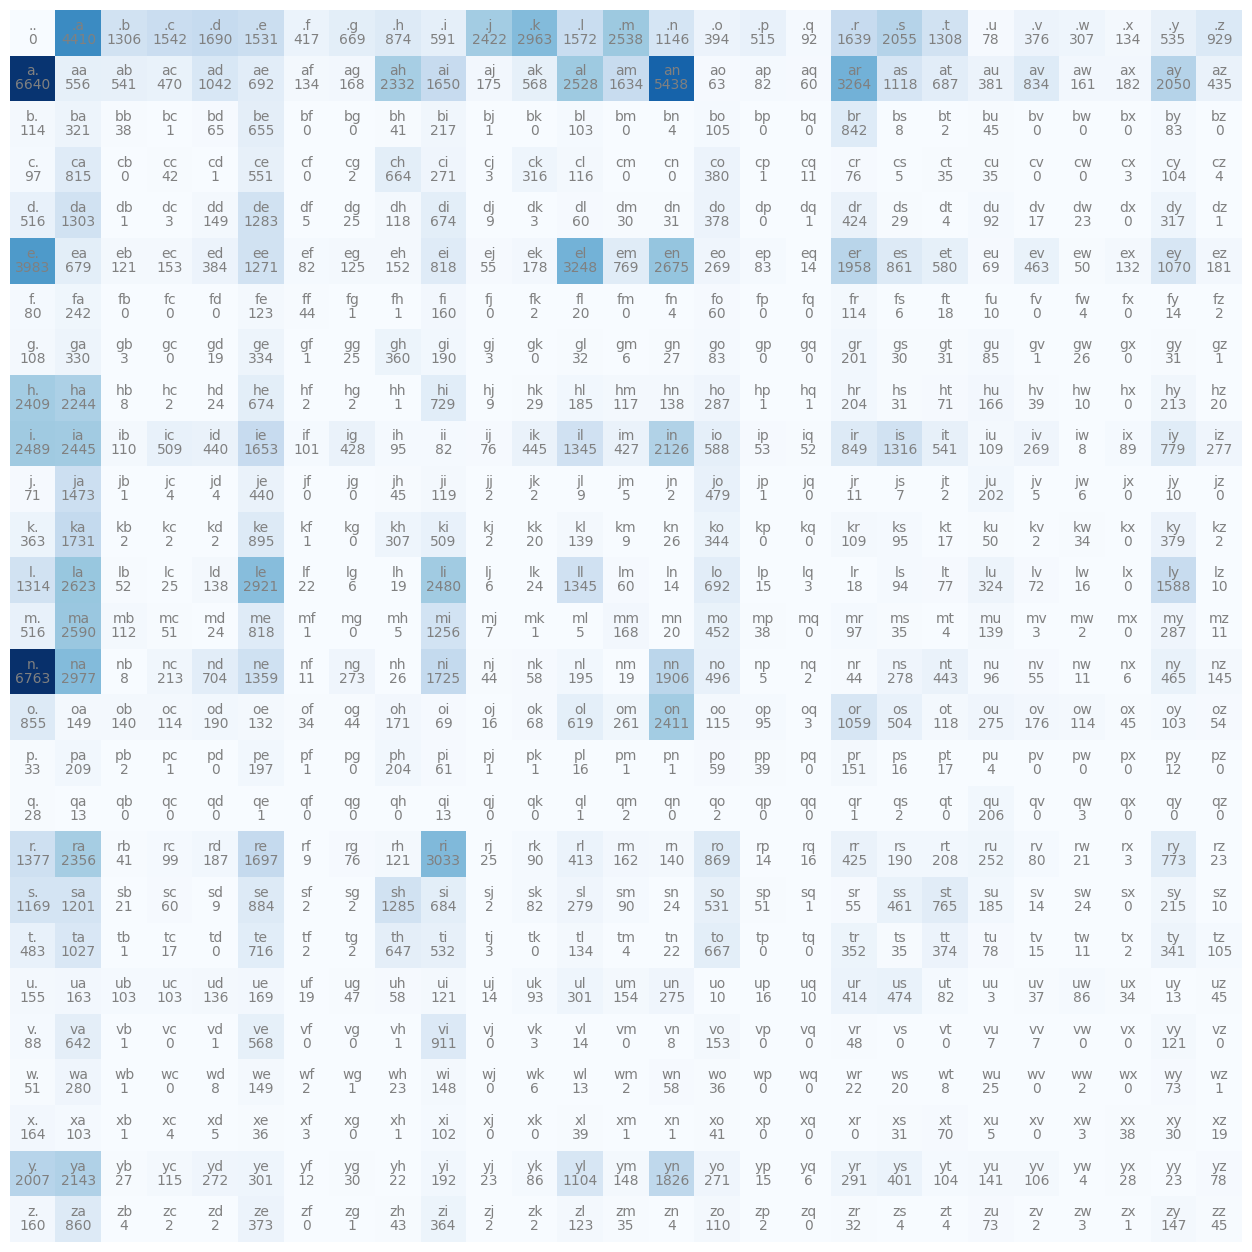

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [17]:
P = (N+1).float()
P /= P.sum(1,keepdims=True)
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()
        out.append(itos[ix])
        if ix==0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


In [18]:
import torch

xs,ys = [], []

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2] #字符转为数字索引

        xs.append(ix1)  #分别放进输入集和目标集
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)


print(f"数据总量：{xs.nelement()}个字符")
print("xs(输入):",xs[5:])
print("ys(目标):",ys[5:])

数据总量：228146个字符
xs(输入): tensor([ 0, 15, 12,  ..., 25, 26, 24])
ys(目标): tensor([15, 12,  9,  ..., 26, 24,  0])


In [19]:
import torch.nn.functional as F

#将输入序列处理为One Hot编码
xenc = F.one_hot(xs,27).float()

print("One-Hot 编码后的张量形状:", xenc.shape)
print("原本的数字 xs[0]:", xs[0].item())
print("One-Hot 编码后的 xs[0]:", xenc[0])

One-Hot 编码后的张量形状: torch.Size([228146, 27])
原本的数字 xs[0]: 0
One-Hot 编码后的 xs[0]: tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.])


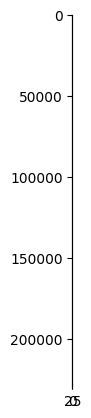

In [25]:
plt.imshow(xenc)

In [23]:
#1、初始化神经网络权重矩阵
g = torch.Generator().manual_seed(2147483647)#随机种子，确保生成的一样

W = torch.randn((27,27),generator=g,requires_grad=True)


#2、矩阵乘法
logits = xenc @ W

#3、得分转概率
counts = logits.exp()
probs = counts / counts.sum(1,keepdims = True)

print("预测概率 probs 的形状:", probs.shape)
print("第一行的概率和:", probs[0].sum().item()) # 应该完美等于 1.0

预测概率 probs 的形状: torch.Size([228146, 27])
第一行的概率和: 1.0000001192092896


In [30]:
import torch.nn.functional as F

# 1. 初始化网络大脑
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

# 统计一下我们到底有多少个字符对样本
num_examples = xs.nelement()
print(f"总样本数: {num_examples}")

epochs = 200
learning_rate = -50.0

#2、梯度下降循环
for epoch in range(epochs):
    xenc = F.one_hot(xs,num_classes=27).float()
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1,keepdims=True)

    #损失计算负对数似然（NLL）
    correct_probs = probs[torch.arange(num_examples),ys]
    loss = -correct_probs.log().mean()

    #梯度清空
    W.grad = None

    loss.backward()

    W.data += learning_rate*W.grad

    if epoch%10 == 0:
        print(f"Epoch{epoch:3d} | Loss:{loss.item():.4f}")

print(f"Final Loss：{loss.item():.4f}")

总样本数: 228146
Epoch  0 | Loss:3.7590
Epoch 10 | Loss:2.6890
Epoch 20 | Loss:2.5728
Epoch 30 | Loss:2.5302
Epoch 40 | Loss:2.5087
Epoch 50 | Loss:2.4961
Epoch 60 | Loss:2.4880
Epoch 70 | Loss:2.4824
Epoch 80 | Loss:2.4783
Epoch 90 | Loss:2.4751
Epoch100 | Loss:2.4727
Epoch110 | Loss:2.4707
Epoch120 | Loss:2.4690
Epoch130 | Loss:2.4677
Epoch140 | Loss:2.4666
Epoch150 | Loss:2.4656
Epoch160 | Loss:2.4648
Epoch170 | Loss:2.4640
Epoch180 | Loss:2.4634
Epoch190 | Loss:2.4628
Final Loss：2.4624


In [31]:
# 设定和之前一模一样的随机种子，为了见证奇迹的时刻
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  out = []
  ix = 0 # 永远从特殊的起始符 '.' (索引 0) 开始
  
  while True:
    # --- 神经网络前向传播 ---
    # 1. 把当前字母变成输入张量，并进行 One-Hot 编码
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    
    # 2. 穿过神经网络的大脑 (矩阵乘法)
    logits = xenc @ W 
    
    # 3. Softmax 层：把得分变成加起来等于 1 的概率分布
    counts = logits.exp()
    p = counts / counts.sum(1, keepdims=True) 
    
    # --- 抽卡阶段 ---
    # 根据神经网络算出来的概率 p，抽出下一个字母的索引
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    
    # 翻译回字母并记录
    out.append(itos[ix])
    
    # 如果抽到结束符 '.'，打破循环
    if ix == 0:
      break
      
  print(''.join(out))

cexze.
momasurailezityha.
konimittain.
llayn.
ka.
